# Packed obs products: fixed vs fixed_sys vs gatti

`shape_noise_comparison.ipynb` checked a single noise-only mock and asked whether the survey-systematics imprint
survives the Poisson draw into the shear noise. This notebook goes one step further down the chain: it reads the
three `fiducial_bench_source_clustering_*_obs_maps.h5` files directly, the packed `obs/maps` + `obs/cls_raw`
products of `observation.forward_model_observation_map` for all 80 `fiducial_bench` realizations, i.e. exactly what
`run_mcmc`/the trained flow consume. That is one level past `count_maps_desy3.ipynb` (source density) and
`shape_noise_comparison.ipynb` (single-mock shear noise): post mode-removal, post scale-cut, post smoothing,
batched over the full mock ensemble.

## Why

`unblinding_plots/3_mock_contamination_sigma8_0.3sigma.png` of `v3_cls/ensemble_flow_190000` overlays the posterior
of every benchmark mock against the fiducial baseline. `fiducial_bench_source_clustering_fixed` (count-based
Poisson resampling, per-cosmology bias, **no** survey systematics) and `..._fixed_sys` (same, **with** the DES Y3
imaging systematics imprinted on the source density before the resampling) sit almost on top of each other, which is
surprising: `fixed_sys` is fit against its own contaminated bias table (`desy3_metacal_bias_sys.h5`), and the
refit absorbs some but not all of the contamination — bin 4 goes from $b=3.06$ (clean) to $b=1.98$ (contaminated),
see the cross-reference note in `pipelines/v17/esub/obs_commands.sh`. `..._gatti` (calibrated density-modulated
noise, cosmology-independent $b_{sc}=1$ for every bin, no survey systematics) sits visibly further out.

## The three arms

| suffix        | `msfm_config`                       | shape_noise.method | bias  | survey_systematics |
|---------------|--------------------------------------|---------------------|-------|---------------------|
| `fixed`       | `configs/v16/sc_fixed.yaml`          | `count`             | fixed | False               |
| `fixed_sys`   | `configs/v17/mocks/sc_fixed_sys.yaml`| `count`             | fixed | **True**            |
| `gatti`       | `configs/v16/sc_gatti.yaml`          | `gatti`              | fixed | False (not defined) |

All three configs share the same pixel file (`data/desy3_pixels_fiducial_512.h5`), the same `n_side=512`, the
same unsmoothed hard scale cut ($\ell_\mathrm{min}=30$, no beam), and the same galaxy-clustering block — only the
metacal shape-noise generator differs. That last point turns out to matter a lot below.

In [1]:
import os

import h5py
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, power_spectra, imports

hp = imports.import_healpy()

# Geometry, channels and the padding mask

`obs/maps` is a padded data vector (NEST, `n_side=512`); `files.get_dv_mask` returns a single boolean mask flagging
the real (non-padding) entries, shared by *every* channel — `files.py` asserts as much (`get_dv_mask` checks the
metacal and maglim masks are identical bin to bin and probe to probe). Channels 0-3 are the metacal (lensing)
$\kappa_E$ maps, mean-subtracted per patch by the mode removal; channels 4-7 are the maglim (clustering) galaxy
counts. `obs/cls_raw` stacks the un-binned auto+cross spectra of all 8 channels, ordered 11,12,...,18,22,...,88 (36
pairs), which `power_spectra.bin_according_to_config` turns into the 32 $\ell$-bins the network actually sees.

In [2]:
repo_dir = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model"
# only the shape_noise block differs between the three arms' configs; geometry/clustering/binning are common
conf = files.load_config(os.path.join(repo_dir, "configs/v17/mocks/sc_fixed_sys.yaml"))

n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)
metacal_bins = conf["survey"]["metacal"]["z_bins"]
maglim_bins = conf["survey"]["maglim"]["z_bins"]
z_labels = metacal_bins + maglim_bins
n_z = len(z_labels)

data_vec_pix, _, _, _ = files.load_pixel_file(conf)
valid = files.get_dv_mask(conf)

print(f"n_side={n_side}, data vector length {len(data_vec_pix)} ({valid.mean():.1%} real pixels, rest padding)")
print("channels:", z_labels)

n_side=512, data vector length 458752 (69.5% real pixels, rest padding)
channels: ['metacal1', 'metacal2', 'metacal3', 'metacal4', 'maglim1', 'maglim2', 'maglim3', 'maglim4']


In [3]:
obs_dir = "/users/athomsen/scratch/deep_lss/data/v17/baseline/obs"
file_tpl = "fiducial_bench_source_clustering_{}_obs_maps.h5"
colors = {"fixed": "C0", "fixed_sys": "C2", "gatti": "C1"}

arms = {}
for name in colors:
    with h5py.File(os.path.join(obs_dir, file_tpl.format(name)), "r") as f:
        arms[name] = {"maps": f["obs/maps"][:], "cls_raw": f["obs/cls_raw"][:]}
    m, c = arms[name]["maps"], arms[name]["cls_raw"]
    print(f"{name:10s} maps {m.shape} cls_raw {c.shape}  finite: {np.isfinite(m).all() and np.isfinite(c).all()}")

n_mocks = arms["fixed"]["maps"].shape[0]

fixed      maps (80, 458752, 8) cls_raw (80, 1536, 36)  finite: True
fixed_sys  maps (80, 458752, 8) cls_raw (80, 1536, 36)  finite: True
gatti      maps (80, 458752, 8) cls_raw (80, 1536, 36)  finite: True


# 1. The clustering channels are bit-identical

Before comparing anything statistically: the four maglim channels are not just similar between arms, they are
byte-for-byte identical. `source_clustering` is purely a metacal/shape-noise concept — the clustering block of the
three configs is untouched, and `run_single_postprocessing.py` derives the per-(permutation, patch) noise seed the
same way regardless of arm, so the galaxy-clustering forward model (density, bias, Poisson draw) sees the same LSS
and the same seed in all three files. Half of the 8 packed channels therefore carry **zero** information that could
distinguish `fixed`/`fixed_sys`/`gatti` — whatever the posterior overlay shows has to come entirely from the 4
lensing channels.

In [4]:
for i in range(4, 8):
    eq_sys = np.array_equal(arms["fixed"]["maps"][..., i], arms["fixed_sys"]["maps"][..., i])
    eq_gatti = np.array_equal(arms["fixed"]["maps"][..., i], arms["gatti"]["maps"][..., i])
    print(f"{z_labels[i]:10s}  fixed == fixed_sys: {eq_sys!s:5s}  fixed == gatti: {eq_gatti!s:5s}")

maglim1     fixed == fixed_sys: True   fixed == gatti: True 
maglim2     fixed == fixed_sys: True   fixed == gatti: True 
maglim3     fixed == fixed_sys: True   fixed == gatti: True 
maglim4     fixed == fixed_sys: True   fixed == gatti: True 


# 2. Lensing channels: mean shift vs. mock-to-mock scatter

The natural map-level summary is the per-mock, per-channel spatial statistic over the 80 realizations, compared to
how much that statistic already scatters from mock to mock (independent LSS *and* noise per mock, since
`fiducial_bench` draws a fresh permutation per index). If the arm-to-arm shift is small compared to that scatter,
a posterior built from these maps has little hope of resolving it either.

The spatial **mean** is not useful here — `mode_removal(..., remove_mean=True)` zeros it per patch by construction,
so it is a null test independent of the shape-noise model. The spatial **std** (map power) is not: it is exactly the
quantity the count/gatti resampling and the systematics imprint can change, since they act on the shape-noise
variance, not the mean.

In [5]:
spatial_std = {name: arms[name]["maps"][:, valid, :4].std(axis=1) for name in arms}  # (n_mocks, 4)

print(f"{'channel':10s} {'std(fixed)':>12s} {'mock scatter':>14s} {'shift fixed_sys':>17s} {'shift gatti':>13s}")
for i, z in enumerate(metacal_bins):
    sf, ss, sg = spatial_std["fixed"][:, i], spatial_std["fixed_sys"][:, i], spatial_std["gatti"][:, i]
    scatter = sf.std()
    shift_sys = (ss.mean() - sf.mean()) / scatter
    shift_gatti = (sg.mean() - sf.mean()) / scatter
    print(
        f"{z:10s} {sf.mean():12.5f} {scatter:14.6f} "
        f"{shift_sys:13.2f} sigma {shift_gatti:11.2f} sigma"
    )

channel      std(fixed)   mock scatter   shift fixed_sys   shift gatti
metacal1        0.02729       0.000090         -1.37 sigma        7.00 sigma
metacal2        0.02943       0.000071         -0.33 sigma        7.17 sigma
metacal3        0.02950       0.000078          0.53 sigma        4.45 sigma
metacal4        0.03623       0.000090         -2.81 sigma       -0.65 sigma


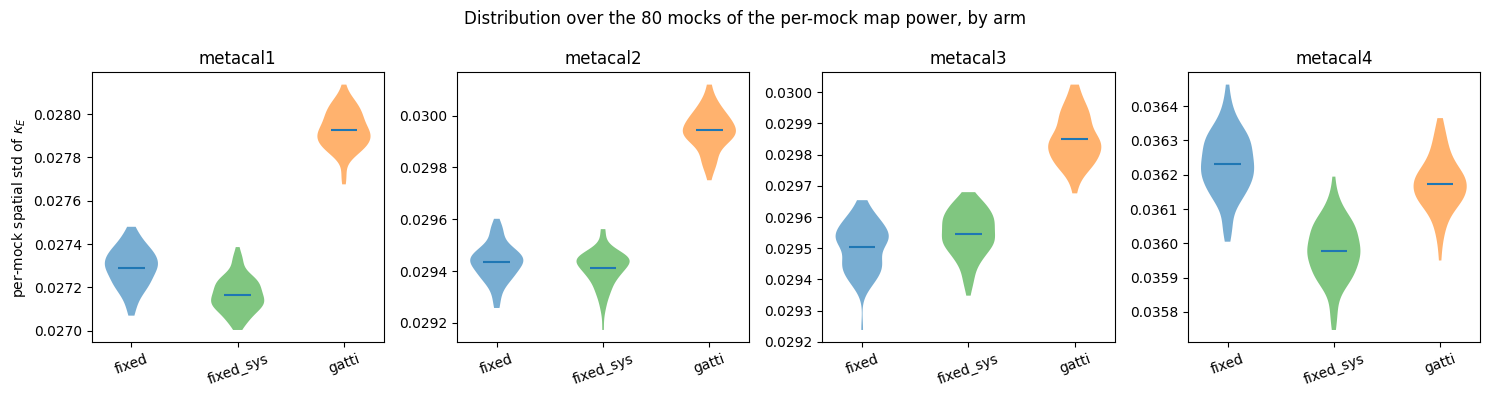

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
for i, (ax, z) in enumerate(zip(axes, metacal_bins)):
    data = [spatial_std[name][:, i] for name in colors]
    parts = ax.violinplot(data, showmeans=True, showextrema=False)
    for pc, name in zip(parts["bodies"], colors):
        pc.set_facecolor(colors[name])
        pc.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(colors.keys(), rotation=20)
    ax.set_title(z)
    if i == 0:
        ax.set_ylabel(r"per-mock spatial std of $\kappa_E$")
fig.suptitle("Distribution over the 80 mocks of the per-mock map power, by arm")
fig.tight_layout()

# 3. Same diagnostic in harmonic space

`power_spectra.bin_according_to_config` reproduces the 32-bin, $\ell\in[30,1500]$ binning the network is trained on.
For each auto-spectrum, the shift of the ensemble-mean $C_\ell$ is expressed in units of the **single-mock** scatter
(not the standard error of the mean) — that is the noise floor an individual mock's likelihood actually sits in, so
it is the fair comparison for "would one posterior notice this".

In [7]:
binned = {}
for name in arms:
    binned[name], bin_edges = power_spectra.bin_according_to_config(arms[name]["cls_raw"], conf)
ell = 0.5 * (bin_edges[:-1, 0] + bin_edges[1:, 0])

pairs = [(i, j) for i in range(n_z) for j in range(i, n_z)]
auto_idx = [k for k, (i, j) in enumerate(pairs) if i == j]
assert len(pairs) == 36 and [z_labels[i] for i, j in pairs if i == j] == z_labels

print(f"{'channel':10s} {'median|shift| sys':>19s} {'max|shift| sys':>16s} {'median|shift| gatti':>21s} {'max|shift| gatti':>18s}")
for i in range(4):
    k = auto_idx[i]
    cf, cs, cg = binned["fixed"][:, :, k], binned["fixed_sys"][:, :, k], binned["gatti"][:, :, k]
    shift_sys = (cs.mean(axis=0) - cf.mean(axis=0)) / cf.std(axis=0)
    shift_gatti = (cg.mean(axis=0) - cf.mean(axis=0)) / cf.std(axis=0)
    print(
        f"{metacal_bins[i]:10s} {np.median(np.abs(shift_sys)):17.3f} sigma {np.max(np.abs(shift_sys)):14.3f} sigma "
        f"{np.median(np.abs(shift_gatti)):19.3f} sigma {np.max(np.abs(shift_gatti)):16.3f} sigma"
    )

channel      median|shift| sys   max|shift| sys   median|shift| gatti   max|shift| gatti
metacal1               0.444 sigma          1.018 sigma               2.517 sigma            4.652 sigma
metacal2               0.121 sigma          0.405 sigma               2.026 sigma            3.951 sigma
metacal3               0.162 sigma          0.668 sigma               1.247 sigma            2.825 sigma
metacal4               0.710 sigma          1.678 sigma               0.190 sigma            0.520 sigma


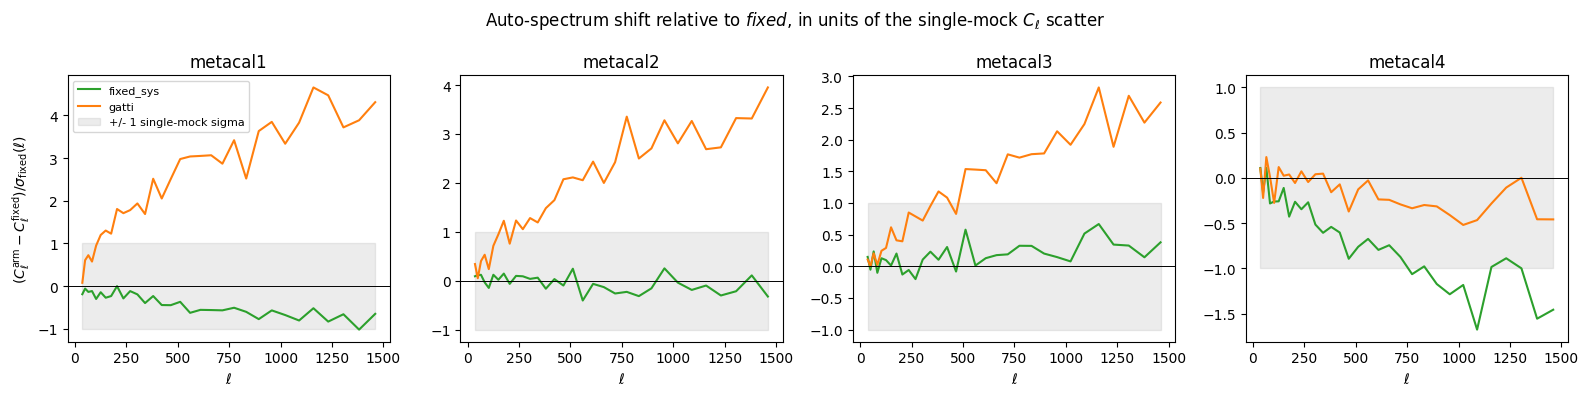

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True)
for i, (ax, z) in enumerate(zip(axes, metacal_bins)):
    k = auto_idx[i]
    cf = binned["fixed"][:, :, k]
    for name in ("fixed_sys", "gatti"):
        c = binned[name][:, :, k]
        shift = (c.mean(axis=0) - cf.mean(axis=0)) / cf.std(axis=0)
        ax.plot(ell, shift, color=colors[name], label=name)
    ax.axhline(0, color="k", lw=0.7)
    ax.fill_between(ell, -1, 1, color="grey", alpha=0.15, label="+/- 1 single-mock sigma" if i == 0 else None)
    ax.set_title(z)
    ax.set_xlabel(r"$\ell$")
    if i == 0:
        ax.set_ylabel(r"$(C_\ell^\mathrm{arm} - C_\ell^\mathrm{fixed}) / \sigma_\mathrm{fixed}(\ell)$")
        ax.legend(fontsize=8)
fig.suptitle(r"Auto-spectrum shift relative to $fixed$, in units of the single-mock $C_\ell$ scatter")
fig.tight_layout()

# 4. Sky maps: one shared mock

Since the three arms process the same `fiducial_bench` permutations with the same `noise_seed` formula, a fixed mock
index carries the same LSS realization (and, for `fixed`/`fixed_sys`, the same Poisson draw before the systematics
multiply in) across all three files — a difference map isolates the arm's own effect rather than mock-to-mock
scatter. `metacal4` is both the most contaminated bin (22.2% imaging-systematics amplitude, vs. the fitted bias
change 3.06 -> 1.98) and the largest std shift measured above, so it is the most informative panel.

In [9]:
i_z = metacal_bins.index("metacal4")
i_mock = 0

lon, lat = hp.vec2ang(
    np.array(hp.pix2vec(n_side, data_vec_pix[valid], nest=True)).mean(axis=1), lonlat=True
)
GNOM = dict(rot=(lon[0], lat[0]), reso=7, xsize=700, ysize=400)


def masked(values):
    '''Scatter a valid-pixel data-vector slice onto the full NEST sky, everything else grey.'''
    full = np.full(n_pix, hp.UNSEEN)
    full[data_vec_pix[valid]] = values[valid]
    return hp.ma(full)


print(f"footprint centred at (lon, lat) = ({lon[0]:.1f}, {lat[0]:.1f}) deg, mock #{i_mock}, channel {metacal_bins[i_z]}")

footprint centred at (lon, lat) = (104.4, -44.3) deg, mock #0, channel metacal4


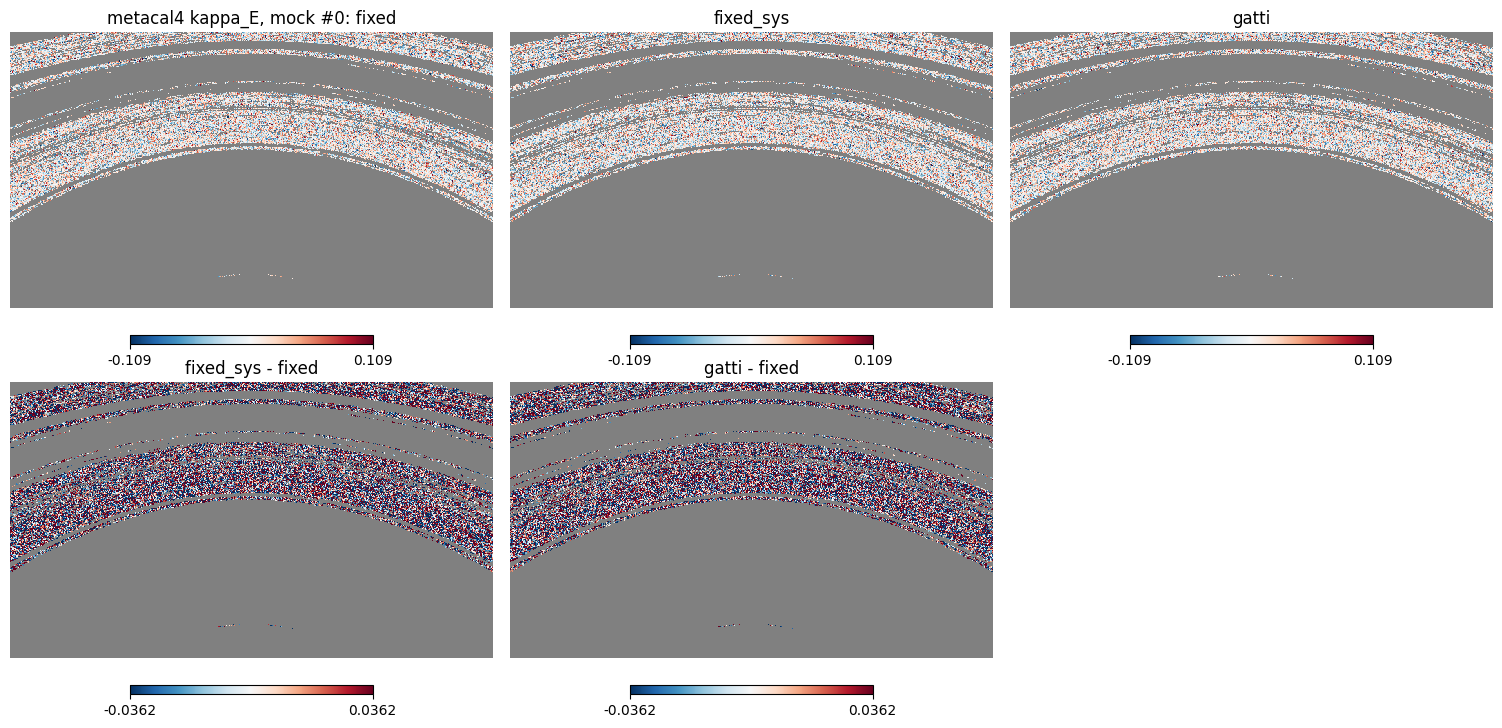

In [10]:
maps_i = {name: arms[name]["maps"][i_mock, :, i_z] for name in colors}
lim = 3 * maps_i["fixed"][valid].std()
label = f"metacal4 kappa_E, mock #{i_mock}"

fig = plt.figure(figsize=(15, 7))
panels = [
    (maps_i["fixed"], f"{label}: fixed", (-lim, lim), "RdBu_r"),
    (maps_i["fixed_sys"], "fixed_sys", (-lim, lim), "RdBu_r"),
    (maps_i["gatti"], "gatti", (-lim, lim), "RdBu_r"),
    (maps_i["fixed_sys"] - maps_i["fixed"], "fixed_sys - fixed", (-lim / 3, lim / 3), "RdBu_r"),
    (maps_i["gatti"] - maps_i["fixed"], "gatti - fixed", (-lim / 3, lim / 3), "RdBu_r"),
    (None, None, None, None),
]
for i, (m, title, lim_j, cmap) in enumerate(panels):
    if m is None:
        continue
    hp.gnomview(
        masked(m), min=lim_j[0], max=lim_j[1], cmap=cmap, title=title, notext=True, cbar=True,
        sub=(2, 3, i + 1), **GNOM,
    )

# 5. The local noise-power envelope, averaged over all 80 mocks

`shape_noise_comparison.ipynb` downgraded a single noise-only realization's $g_1^2+g_2^2$ to `nside_low` to reveal
the envelope the shot noise sits in. Here the same trick is applied to $\kappa_E^2$ of the packed maps, mock-averaged
first (each fine pixel's $\langle\kappa_E^2\rangle$ is its own mean over the 80 realizations) and then downgraded, so
that the LSS- and noise-driven part of the per-pixel scatter — which differs from mock to mock and averages down —
is separated from whatever is tied to the fixed DES Y3 depth map, which does not.

**Caveat before reading the ratio panels**: coarsening from `nside_low=32` down to 8 barely reduces their pixel-to-
pixel scatter (~17% -> ~12%, not the ~4x a white-noise floor would give for 16x more fine pixels per bin), so the
scatter is not simply the residual sampling noise of 80 mocks — it has real spatial structure at the few-to-tens-of-
percent level, the same order as the DES Y3 contamination amplitude itself (5.7-22.2% per pixel, `count_maps_desy3`
Section 3). It does not, however, resolve into a clean by-eye pattern at this mock count; that is itself consistent
with the sub-2-sigma integrated shift of Sections 2-3 rather than a contradiction of it.

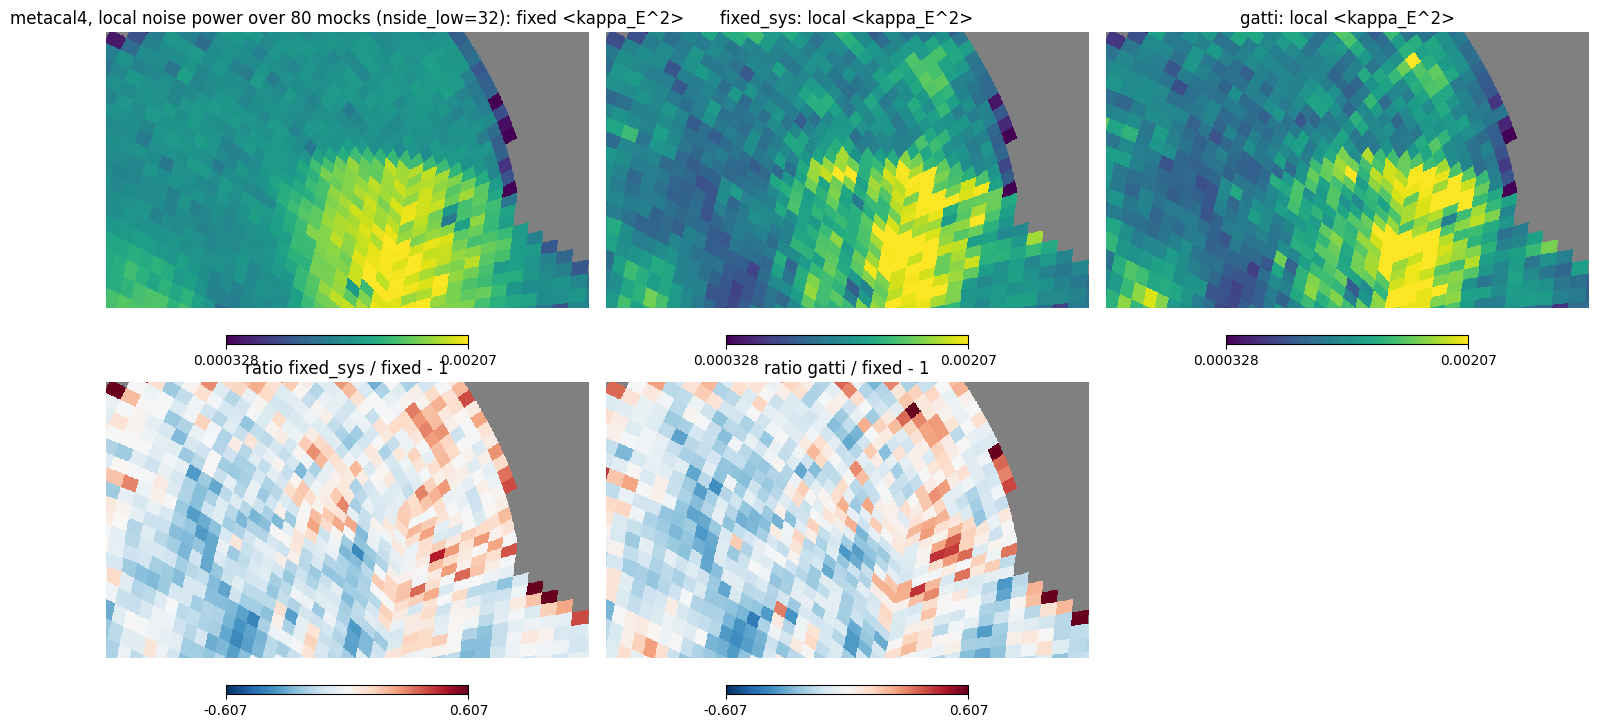

In [11]:
nside_low = 32


def local_power(map_2d, valid_mask, nside_low=nside_low):
    '''Downgrade E[values^2] over (mock, pixel) to nside_low, averaging over populated fine pixels only.

    Args:
        map_2d (np.ndarray): Shape (n_mocks, n_pix_dv) slice of one channel, NEST data-vector order.
        valid_mask (np.ndarray): Boolean data-vector mask of the real (non-padding) entries.

    Returns:
        np.ndarray: nside_low NEST full-sky map of the mock-and-pixel averaged square, hp.UNSEEN outside.
    '''
    full_sq = np.zeros(n_pix, dtype=np.float64)
    full_n = np.zeros(n_pix, dtype=np.float64)
    pix = data_vec_pix[valid_mask]
    full_sq[pix] = np.mean(map_2d[:, valid_mask] ** 2, axis=0)
    full_n[pix] = 1.0

    low_sq = hp.ud_grade(full_sq, nside_low, order_in="NESTED", order_out="NESTED", power=-2)
    low_n = hp.ud_grade(full_n, nside_low, order_in="NESTED", order_out="NESTED", power=-2)

    out = np.full(hp.nside2npix(nside_low), hp.UNSEEN)
    occ = low_n > 0
    out[occ] = low_sq[occ] / low_n[occ]
    return out


power_maps = {name: local_power(arms[name]["maps"][:, :, i_z], valid) for name in colors}
occ = power_maps["fixed"] != hp.UNSEEN
ratio_sys = np.where(occ, power_maps["fixed_sys"] / np.where(occ, power_maps["fixed"], 1) - 1, hp.UNSEEN)
ratio_gatti = np.where(occ, power_maps["gatti"] / np.where(occ, power_maps["fixed"], 1) - 1, hp.UNSEEN)

lim_pow = np.percentile(power_maps["fixed"][occ], (1, 99))
lim_ratio = 3 * ratio_sys[occ].std()
label = f"metacal4, local noise power over {n_mocks} mocks (nside_low={nside_low})"

fig = plt.figure(figsize=(15, 7))
panels = [
    (power_maps["fixed"], f"{label}: fixed <kappa_E^2>", lim_pow, "viridis"),
    (power_maps["fixed_sys"], "fixed_sys: local <kappa_E^2>", lim_pow, "viridis"),
    (power_maps["gatti"], "gatti: local <kappa_E^2>", lim_pow, "viridis"),
    (ratio_sys, "ratio fixed_sys / fixed - 1", (-lim_ratio, lim_ratio), "RdBu_r"),
    (ratio_gatti, "ratio gatti / fixed - 1", (-lim_ratio, lim_ratio), "RdBu_r"),
    (None, None, None, None),
]
for i, (m, title, lim_j, cmap) in enumerate(panels):
    if m is None:
        continue
    hp.gnomview(
        hp.ma(m), min=lim_j[0], max=lim_j[1], cmap=cmap, title=title, notext=True, cbar=True,
        nest=True, sub=(2, 3, i + 1), **GNOM,
    )

# Where this sits in the chain

- `sc_bias_fit_count.ipynb` — where the per-cosmology biases both other notebooks read come from, including the
  contaminated bias table `fixed_sys` refits against.
- `count_maps_desy3.ipynb` — the noise-free source-density rate and one Poisson realization of the counts, by eye.
- `shape_noise_comparison.ipynb` — whether the imprint survives the Poisson draw and catalog resampling into a
  single noise-only shear realization.
- **this notebook** — the actual packed, scale-cut, network-facing products, across the full 80-mock benchmark
  ensemble, at the same channel/binning the trained flow consumes.

## Reading the unblinding overlay

- The 4 clustering channels are **exactly** identical across all three arms (Section 1) — `source_clustering` is a
  metacal-only concept, so half the summary the network is handed cannot move at all between `fixed` and
  `fixed_sys`/`gatti`.
- Within the 4 lensing channels, the spatial mean is a null test by construction (mode removal); the map power and
  the auto-spectra put the `fixed_sys` shift at a fraction of a single mock's own scatter in most bins, growing to
  a few sigma only in `metacal4` (Sections 2-3) — consistent with `metacal4` carrying both the largest contamination
  amplitude (22.2%) and the largest bias re-fit (3.06 -> 1.98).
- `gatti` moves several sigma more than `fixed_sys` does, in the opposite direction in `metacal4` — it is a
  genuinely different generative model (density-modulated real catalog vs. re-biased Poisson resampling), not a
  survey-systematics effect, and that is the arm visibly offset in the corner plot.

So the near-overlap of `fixed` and `fixed_sys` in the unblinding plot is not a fluke of the flow washing out a large
effect: at the level of what the network is fed, the survey-systematics imprint is a small perturbation of a few
percent in `metacal4` only, riding on top of a combined 8-channel summary half of which cannot see it at all.